In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

path = "/Users/taytematthews/Backtesting Data/S&P 500 Historical Components & Changes(01-17-2026) (1).csv"

ticker_history = pd.read_csv(path)

start = pd.Timestamp("1999-01-01")
analysis_end = pd.Timestamp("2019-12-31")  # used for common_tickers and ranking
data_end = pd.Timestamp("2025-12-31")      # used for price download to cover the backtest period

ticker_history["date"] = pd.to_datetime(ticker_history["date"])

th_filtered = ticker_history[
    (ticker_history["date"] >= start) &
    (ticker_history["date"] <= analysis_end)  # only 1999-2019 to avoid survivorship bias
]

ticker_sets = th_filtered["tickers"].str.split(",").map(set)
common_tickers = set.intersection(*ticker_sets) if len(ticker_sets) > 0 else set()
len(common_tickers)

196

In [127]:
import os

DATA_CACHE = "/Users/taytematthews/June Backtesting Repo/price_data_cache.pkl"

if os.path.exists(DATA_CACHE):
    data = pd.read_pickle(DATA_CACHE)
    print(f"Loaded cached data from {DATA_CACHE}")
else:
    data = yf.download(
        sorted(common_tickers),
        start=start, end=data_end,  # full range 1999-2025 so backtest has price data
        auto_adjust=False, group_by="ticker", progress=True
    )
    data.to_pickle(DATA_CACHE)
    print(f"Downloaded and cached data to {DATA_CACHE}")


Loaded cached data from /Users/taytematthews/June Backtesting Repo/price_data_cache.pkl


In [110]:
if isinstance(data.columns, pd.MultiIndex): #checks whether dataframe's columns are MultiIndex (e.g. 'AAPL', 'Open')
    open_prices = data.xs("Open", axis=1, level=1).copy() # xs = cross section. Arguments are (key, axis, level). key = value to select, axis = 1 means columns, level = 1 means look at the second level of the Multiindex
    adj_close_prices = data.xs("Adj Close", axis=1, level=1).copy() #getting the adj close prices by selecting the "Adj Close" level of the MultiIndex columns
    volumes = data.xs("Volume", axis=1, level=1).copy() # getting the volume data by selecting the "Volume" level of the MultiIndex columns
else:
    open_prices = data["Open"].copy() # if not multiindex, just select columns directly by name    
    adj_close_prices = data["Adj Close"].copy()
    volumes = data["Volume"].copy()

In [111]:
####################
## SET TIME FRAME ## 
####################
start_date = pd.Timestamp("1999-01-01") # set start and end date, be sure to go back 1 year before the actual start date of the backtest to allow for the calculation of indicators that require a lookback period (e.g. moving averages, RSI, etc.)
end_date = pd.Timestamp("2019-12-31") 

In [113]:
def compute_recoveries(adj_close_prices, start_date=None, end_date=None, analysis_start=None):

    # Slice to the requested date range (local copy — doesn't modify the global DataFrame)
    if start_date or end_date:
        adj_close_prices = adj_close_prices.loc[start_date:end_date]

    # Default to the first available date if no explicit analysis start is given
    if analysis_start is None:
        analysis_start = adj_close_prices.index[0]

    # min_periods=1 means the rolling window starts immediately rather than waiting
    # for a full 252-day window, so early dates still get a valid high
    rolling_52wk_high = adj_close_prices.rolling(window=252, min_periods=1).max()

    # True wherever a price is 20%+ below its rolling 52-week high
    drawdown_mask = adj_close_prices <= 0.8 * rolling_52wk_high

    recovery_records = []

    for ticker in adj_close_prices.columns:

        prices = adj_close_prices[ticker]

        in_drawdown = False  # tracks whether we're currently inside a drawdown event
        i = 0
        n = len(prices)

        while i < n:

            date = prices.index[i]
            price = prices.iloc[i]

            # --- ENTER DRAWDOWN ---
            # Only start a new drawdown event on or after analysis_start so that
            # the seed year (used purely for the rolling high) doesn't generate signals
            if (not in_drawdown) and drawdown_mask.loc[date, ticker] and date >= analysis_start:

                in_drawdown = True

                drawdown_date = date
                drawdown_price = price

                target_price = drawdown_price * 1.125  # +12.5% from entry = recovery target

                # --- SEARCH FOR RECOVERY ---
                # Scan every future bar from the entry date looking for the first
                # close that hits the recovery target
                recovered = False

                for j in range(i + 1, n):

                    future_price = prices.iloc[j]

                    if future_price >= target_price:

                        recovery_records.append({
                            "Ticker": ticker,
                            "Drawdown Date": drawdown_date,
                            "Drawdown Price": drawdown_price,
                            "Recovery Date": prices.index[j],
                            "Recovery Price": future_price,
                            "Days To Recovery": j - i,  # calendar trading days, not calendar days
                            "Return": (future_price / drawdown_price) - 1
                        })

                        recovered = True
                        break

                # Record the drawdown even if it never recovered (NaN fields)
                # so the scoring step can account for unresolved drawdowns
                if not recovered:

                    recovery_records.append({
                        "Ticker": ticker,
                        "Drawdown Date": drawdown_date,
                        "Drawdown Price": drawdown_price,
                        "Recovery Date": pd.NaT,
                        "Recovery Price": np.nan,
                        "Days To Recovery": np.nan,
                        "Return": np.nan
                    })

            # --- EXIT DRAWDOWN STATE ---
            # Reset the flag once price climbs back above the 80% threshold so the
            # next dip below is treated as a fresh, independent drawdown event
            elif in_drawdown and (not drawdown_mask.loc[date, ticker]):
                in_drawdown = False

            i += 1

    recoveries = pd.DataFrame(recovery_records)

    if len(recoveries) > 0:
        recoveries = recoveries.sort_values(
            ["Drawdown Date", "Ticker"]
        ).reset_index(drop=True)

    return recoveries


In [114]:
recoveries = compute_recoveries(
    adj_close_prices,
    start_date=start_date,       # 1999-01-01 — seeds the rolling 52wk high
    end_date=end_date,
    analysis_start=pd.Timestamp("2000-01-01")  # drawdowns counted from here
)
print(recoveries.head(20))

   Ticker Drawdown Date  Drawdown Price Recovery Date  Recovery Price  \
0     ABT    2000-01-03        8.042603    2000-04-04        9.106842   
1     ADM    2000-01-03        5.929681    2000-11-30        6.740346   
2    ADSK    2000-01-03        8.052906    2000-02-08        9.549117   
3     AEP    2000-01-03       10.064173    2000-04-24       11.407821   
4     ALL    2000-01-03       12.401284    2000-05-15       14.298413   
5     APA    2000-01-03       10.046666    2000-01-18       11.445105   
6     APD    2000-01-03       16.348267    2000-05-23       19.366829   
7     BAC    2000-01-03       12.356369    2000-03-23       13.975095   
8     BDX    2000-01-03       13.284971    2000-02-18       15.504423   
9     BEN    2000-01-03        5.050139    2000-01-24        5.707552   
10    BSX    2000-01-03       11.500000    2000-04-25       13.937500   
11    CAG    2000-01-03        6.681649    2000-11-16        7.548602   
12    CAH    2000-01-03       14.777143    2000-01-

In [115]:
from scipy import stats

def make_period_bins(start_date, end_date, step=5):
    start_year = pd.to_datetime(start_date).year
    end_year   = pd.to_datetime(end_date).year
    # Floor to the nearest multiple of step so bins always start on a clean boundary
    # e.g. 2003 with step=5 → 2000, not 2003
    start_bin  = (start_year // step) * step
    end_bin    = ((end_year  // step) + 1) * step
    bins   = list(range(start_bin, end_bin + 1, step))
    # Labels are "2000-2004", "2005-2009", etc. — right edge is exclusive in pd.cut
    labels = [f"{bins[i]}-{bins[i+1]-1}" for i in range(len(bins) - 1)]
    return bins, labels


def compute_scores(recoveries, start_date, end_date, weights=(1, 1, 1)):
    w_dd, w_rec, w_var = weights

    # Count drawdown events and average recovery time per ticker
    summary = recoveries.groupby("Ticker").agg(
        drawdown_count    = ("Ticker", "count"),
        avg_recovery_days = ("Days To Recovery", "mean")
    ).reset_index()

    # Normalize to [0, 1] so both metrics are on the same scale before z-scoring
    summary["drawdown_score"] = (
        (summary["drawdown_count"] - summary["drawdown_count"].min()) /
        (summary["drawdown_count"].max() - summary["drawdown_count"].min())
    )
    # Invert recovery days: faster recovery → higher score
    summary["recovery_score"] = 1 - (
        (summary["avg_recovery_days"] - summary["avg_recovery_days"].min()) /
        (summary["avg_recovery_days"].max() - summary["avg_recovery_days"].min())
    )

    # Z-score so each component has mean=0, std=1 — prevents one metric from
    # dominating the final score just because of its raw magnitude
    summary["drawdown_score_zscore"] = stats.zscore(summary["drawdown_score"])
    summary["recovery_score_zscore"] = stats.zscore(summary["recovery_score"])

    # Split drawdown history into 5-year periods to measure consistency over time
    period_bins, period_labels = make_period_bins(start_date, end_date, step=5)

    df_period = recoveries.copy()
    df_period["Drawdown Period"] = pd.cut(
        df_period["Drawdown Date"].dt.year,
        bins=period_bins,
        labels=period_labels,
        right=False,  # left-inclusive: [2000, 2005), [2005, 2010), etc.
    )

    # Count how many drawdowns each ticker had in each 5-year bucket
    drawdown_counts = (
        df_period.dropna(subset=["Drawdown Period"])
        .groupby(["Ticker", "Drawdown Period"])
        .size()
        .unstack(fill_value=0)  # missing period → 0 drawdowns, not NaN
        .rename(columns=lambda x: f"drawdowns_{x}")
    )
    drawdown_cols = list(drawdown_counts.columns)

    # Variance across periods measures consistency: a ticker that draws down
    # regularly in every period is more reliable than one that clusters in one era
    drawdown_counts["drawdowns_variance"] = drawdown_counts[drawdown_cols].var(axis=1, ddof=0)
    summary = summary.merge(
        drawdown_counts[["drawdowns_variance"]].reset_index(),
        on="Ticker", how="left"
    )
    var_vals = summary["drawdowns_variance"].fillna(summary["drawdowns_variance"].mean())
    # Negate so that lower variance → higher z-score (more consistent = better rank)
    summary["variance_zscore"] = -stats.zscore(var_vals)

    # Weighted sum of the three z-scored components → final rank
    summary["final_score"] = (
        w_dd  * summary["drawdown_score_zscore"] +
        w_rec * summary["recovery_score_zscore"] +
        w_var * summary["variance_zscore"]
    )

    return (
        summary[["Ticker", "drawdown_score_zscore", "recovery_score_zscore", "variance_zscore", "final_score"]]
        .sort_values("final_score", ascending=False)
        .reset_index(drop=True)
    )


In [126]:
short_summary = compute_scores(recoveries, start_date, end_date)
print(short_summary.head(10))
print(summary_df.to_string(index=False))

  Ticker  drawdown_score_zscore  recovery_score_zscore  variance_zscore  \
0    FCX               2.455561               0.792518         0.389089   
1    KSS               2.280210               0.333789         0.670977   
2    NUE               1.929509               0.355669         0.891448   
3    WFC               1.695708               0.739903         0.689874   
4    ROK               1.754158               0.570681         0.779638   
5    LOW               1.169657               0.712580         0.729244   
6     PH               1.111206               0.805750         0.645780   
7    WHR               1.403457               0.189027         0.867826   
8    CAT               0.935856               0.483180         0.930818   
9    ADM               0.818956               0.465068         0.943416   

   final_score  
0     3.637167  
1     3.284976  
2     3.176626  
3     3.125485  
4     3.104477  
5     2.611480  
6     2.562737  
7     2.460310  
8     2.349853  
9   

In [117]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ============================================================================
# DOWNLOAD S&P 500 DATA FOR BUY-AND-HOLD COMPARISON
# ============================================================================

sp500_data = yf.download('^GSPC', start='2000-01-01', end='2025-12-31', progress=False)
# robustly extract close prices (use Adj Close if available, else Close, else try MultiIndex tuples, else first column)
def _extract_close(df):
    if 'Adj Close' in df.columns:
        return df['Adj Close']
    if 'Close' in df.columns:
        return df['Close']
    if isinstance(df.columns, pd.MultiIndex):
        for col in df.columns:
            name = ' '.join(map(str, col))
            if 'Adj' in name or 'Close' in name:
                return df[col]
    return df.iloc[:, 0]

sp500_prices = _extract_close(sp500_data).squeeze()

In [118]:
# ============================================================================
# PARAMETER SWEEP: PERCENTILE FILTERS AND POSITION SIZES
# ============================================================================

def run_backtest(top_percentile, allocation_pct, backtest_start, backtest_end):
    # Build the eligible ticker universe: only tickers whose final_score is at or
    # above the given percentile floor, sorted best-first so higher-ranked stocks
    # get priority when multiple are in drawdown on the same day
    threshold = short_summary['final_score'].quantile(top_percentile)
    tickers = (short_summary[short_summary['final_score'] >= threshold]
           .sort_values('final_score', ascending=False)
           ['Ticker']
           .tolist())

    portfolio = {
        'cash': INITIAL_CASH,
        'open_positions': {},  # keyed by ticker; each value holds shares, buy price, entry date/idx
    }

    closed_trades = []
    equity_history = []

    dates = adj_close_prices.index  # full 1999-2025 index; loop skips pre-backtest dates below

    for date_idx, date in enumerate(dates):
        if date < backtest_start:
            continue  # skip the seed years used only for the 52-week high warm-up
        if date > backtest_end:
            break

        current_position_equity = 0  # reset and recompute from scratch each day
        tickers_to_close = []

        # --- STEP 1: CHECK EXIT CONDITIONS FOR ALL OPEN POSITIONS ---
        # Collect closes separately first so we don't mutate the dict while iterating it
        for ticker in list(portfolio['open_positions'].keys()):
            if ticker not in adj_close_prices.columns:
                continue
            current_price = adj_close_prices.loc[date, ticker]
            if pd.isna(current_price):
                continue

            position = portfolio['open_positions'][ticker]
            buy_price = position['buy_price']
            shares = position['shares']
            price_return = (current_price / buy_price) - 1
            pnl = (current_price - buy_price) * shares

            if price_return >= PROFIT_TARGET_PCT:
                close_reason = 'TAKE_PROFIT'
            elif price_return <= STOP_LOSS_PCT:
                close_reason = 'STOP_LOSS'
            else:
                close_reason = None

            if close_reason:
                tickers_to_close.append({
                    'ticker': ticker,
                    'price': current_price,
                    'shares': shares,
                    'buy_price': buy_price,
                    'pnl': pnl,
                    'pnl_pct': price_return,
                    'reason': close_reason,
                    'entry_date': position['buy_date'],
                    'entry_time_idx': position['entry_time_idx']
                })

        # --- STEP 2: EXECUTE CLOSES, RETURN PROCEEDS TO CASH ---
        for close in tickers_to_close:
            ticker = close['ticker']
            proceeds = close['price'] * close['shares']
            portfolio['cash'] += proceeds
            closed_trades.append({
                'Ticker': ticker,
                'Entry Date': close['entry_date'],
                'Entry Price': close['buy_price'],
                'Shares': close['shares'],
                'Exit Date': date,
                'Exit Price': close['price'],
                'PnL': close['pnl'],
                'PnL %': close['pnl_pct'],
                'Days Held': date_idx - close['entry_time_idx'],
                'Reason': close['reason']
            })
            del portfolio['open_positions'][ticker]

        # --- STEP 3: VALUE REMAINING OPEN POSITIONS AT TODAY'S CLOSE ---
        for ticker in portfolio['open_positions'].keys():
            if ticker not in adj_close_prices.columns:
                continue
            current_price = adj_close_prices.loc[date, ticker]
            if pd.isna(current_price):
                continue
            position = portfolio['open_positions'][ticker]
            current_position_equity += current_price * position['shares']

        # --- STEP 4: SCAN FOR NEW BUY SIGNALS ---
        # Tickers are iterated in score order so capital is deployed to the best-ranked
        # stocks first when cash is limited
        for ticker in tickers:
            if ticker not in adj_close_prices.columns:
                continue
            if ticker in portfolio['open_positions']:  # already holding this stock
                continue

            current_price = adj_close_prices.loc[date, ticker]
            high_52w = rolling_52wk_high.loc[date, ticker]
            if pd.isna(current_price) or pd.isna(high_52w):
                continue

            drawdown_pct = (current_price / high_52w) - 1
            if drawdown_pct <= -0.20:  # buy signal: 20%+ below 52-week high
                # Size the position as a fixed % of total current equity (cash + open positions)
                total_equity = portfolio['cash'] + current_position_equity
                position_amount = total_equity * allocation_pct
                if portfolio['cash'] >= position_amount and position_amount > 0:
                    shares = position_amount / current_price
                    portfolio['cash'] -= position_amount
                    # Include the new position in today's equity so the end-of-day
                    # snapshot reflects the true portfolio value (not just leftover cash)
                    current_position_equity += current_price * shares
                    portfolio['open_positions'][ticker] = {
                        'shares': shares,
                        'buy_date': date,
                        'buy_price': current_price,
                        'entry_time_idx': date_idx
                    }

        # --- STEP 5: RECORD END-OF-DAY SNAPSHOT ---
        total_equity = portfolio['cash'] + current_position_equity
        equity_history.append({
            'Date': date,
            'Cash': portfolio['cash'],
            'Position Equity': current_position_equity,
            'Total Equity': total_equity,
            'Open Positions': len(portfolio['open_positions'])
        })

    equity_history_df = pd.DataFrame(equity_history)
    closed_trades_df = pd.DataFrame(closed_trades)

    total_return = (equity_history_df['Total Equity'].iloc[-1] / INITIAL_CASH) - 1
    num_years = (equity_history_df['Date'].iloc[-1] - equity_history_df['Date'].iloc[0]).days / 365.25
    ann_return = (1 + total_return) ** (1 / num_years) - 1 if num_years > 0 else 0
    win_rate = (closed_trades_df['PnL'] > 0).mean() if len(closed_trades_df) > 0 else float('nan')
    expected_value = closed_trades_df['PnL'].mean() if len(closed_trades_df) > 0 else float('nan')

    return {
        'percentile': top_percentile,
        'allocation_pct': allocation_pct,
        'ticker_count': len(tickers),
        'final_equity': equity_history_df['Total Equity'].iloc[-1],
        'total_return': total_return,
        'annualized_return': ann_return,
        'num_trades': len(closed_trades_df),
        'win_rate': win_rate,
        'expected_value': expected_value,
        'equity_curve': equity_history_df,
        'closed_trades': closed_trades_df
    }


In [119]:
####################################
## TESTING PARAMETER COMBINATIONS ## 
####################################
backtest_start = pd.Timestamp("2020-01-01")
backtest_end = pd.Timestamp("2025-12-31")
INITIAL_CASH = 100000
PROFIT_TARGET_PCT = 0.125
STOP_LOSS_PCT = -0.20
percentiles = [0,0.25,0.5,0.75]
allocations = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1]
results = []

for pct in percentiles:
    for alloc in allocations:
        # ensure rolling 52-week highs cover the backtest period to avoid KeyError on dates outside prior filtered range
        rolling_52wk_high = adj_close_prices.rolling(window=252, min_periods=1).max()
        result = run_backtest(pct, alloc, backtest_start, backtest_end)
        results.append(result)

summary_df = pd.DataFrame([
    {
        'Percentile': r['percentile'],
        'Position Size': f"{int(r['allocation_pct']*100)}%",
        'Ticker Count': r['ticker_count'],
        'Final Equity': r['final_equity'],
        'Total Return %': r['total_return'] * 100,
        'Annualized Return %': r['annualized_return'] * 100,
        'Trades': r['num_trades'],
        'Win Rate %': r['win_rate'] * 100 if not pd.isna(r['win_rate']) else float('nan'),
        'Expected Value': r['expected_value']
    }
    for r in results
])

summary_df = summary_df.sort_values(['Percentile', 'Position Size']).reset_index(drop=True)
print(summary_df.to_string(index=False))

# You can also access the full equity curve for any scenario using results[n]['equity_curve'].
# Example: results[0] corresponds to 0th percentile / 1% allocation.


 Percentile Position Size  Ticker Count  Final Equity  Total Return %  Annualized Return %  Trades  Win Rate %  Expected Value
       0.00            1%           179 196373.026395       96.373026            11.918726    1866   72.132905       52.274456
       0.00           10%           179 273310.238276      173.310238            18.265780     338   70.118343      544.582910
       0.00            2%           179 224068.851883      124.068852            14.409901    1306   70.980092       97.342092
       0.00            3%           179 247952.482975      147.952483            16.359847    1014   70.414201      150.612807
       0.00            4%           179 249746.892697      149.746893            16.499934     783   70.753512      201.606694
       0.00            5%           179 275871.291673      175.871292            18.449974     659   70.864947      270.980584
       0.00            6%           179 293730.999463      193.730999            19.696294     543   71.086556 

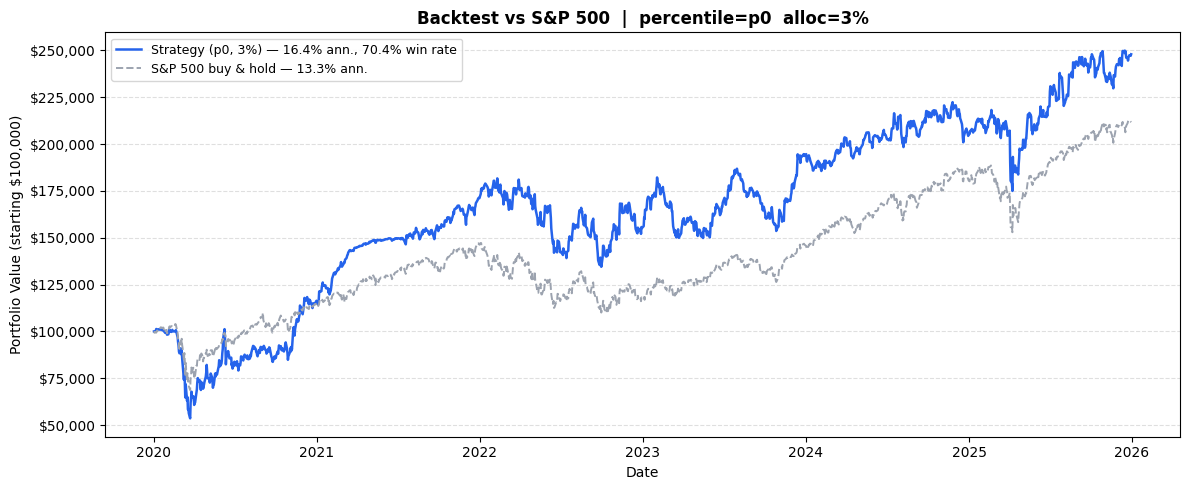

In [120]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_equity_vs_sp500(result, sp500_prices, initial_cash=INITIAL_CASH, title=None):
    """
    Plot a single backtest equity curve against the S&P 500 buy-and-hold.

    Parameters
    ----------
    result       : one element from the `results` list
    sp500_prices : Series of S&P 500 prices (from cell above)
    initial_cash : starting portfolio value for normalisation
    title        : optional string; auto-generated from result metadata if None
    """
    eq = result["equity_curve"].copy()
    eq["Date"] = pd.to_datetime(eq["Date"])
    eq = eq.set_index("Date")

    # Trim S&P 500 to the same date range as the equity curve
    sp = sp500_prices.loc[eq.index[0] : eq.index[-1]].copy()

    # Normalise both series to initial_cash so they start at the same value
    eq_norm = eq["Total Equity"] / eq["Total Equity"].iloc[0] * initial_cash
    sp_norm = sp / sp.iloc[0] * initial_cash

    # ── build label ──────────────────────────────────────────────────────────
    pct_str   = f"p{int(result['percentile'] * 100)}"
    alloc_str = f"{int(result['allocation_pct'] * 100)}%"
    ann       = result["annualized_return"] * 100
    wr        = result["win_rate"] * 100 if not pd.isna(result["win_rate"]) else float("nan")

    sp_total_return = (sp_norm.iloc[-1] / sp_norm.iloc[0] - 1) * 100
    sp_years  = (sp.index[-1] - sp.index[0]).days / 365.25
    sp_ann    = ((1 + sp_total_return / 100) ** (1 / sp_years) - 1) * 100 if sp_years > 0 else float("nan")

    strat_label = f"Strategy ({pct_str}, {alloc_str}) — {ann:.1f}% ann., {wr:.1f}% win rate"
    sp_label    = f"S&P 500 buy & hold — {sp_ann:.1f}% ann."

    auto_title  = f"Backtest vs S&P 500  |  percentile={pct_str}  alloc={alloc_str}"

    # ── plot ─────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(eq_norm.index, eq_norm.values, color="#2563EB", linewidth=1.8, label=strat_label)
    ax.plot(sp_norm.index, sp_norm.values, color="#9CA3AF", linewidth=1.4, linestyle="--", label=sp_label)

    ax.set_title(title or auto_title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Portfolio Value (starting ${initial_cash:,.0f})")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


# ── SELECT WHICH RESULT TO PLOT ───────────────────────────────────────────────
# Change these two values to pick any run from the parameter sweep above.
PLOT_PERCENTILE  = 0        # must match a value in `percentiles`
PLOT_ALLOCATION  = 0.03     # must match a value in `allocations`

match = next(
    (r for r in results
     if r["percentile"] == PLOT_PERCENTILE
     and abs(r["allocation_pct"] - PLOT_ALLOCATION) < 1e-9),
    None
)

if match:
    plot_equity_vs_sp500(match, sp500_prices)
else:
    print(f"No result found for percentile={PLOT_PERCENTILE}, allocation={PLOT_ALLOCATION}."
          f" Available: percentiles={list({r['percentile'] for r in results})}"
          f", allocations={sorted({r['allocation_pct'] for r in results})}")

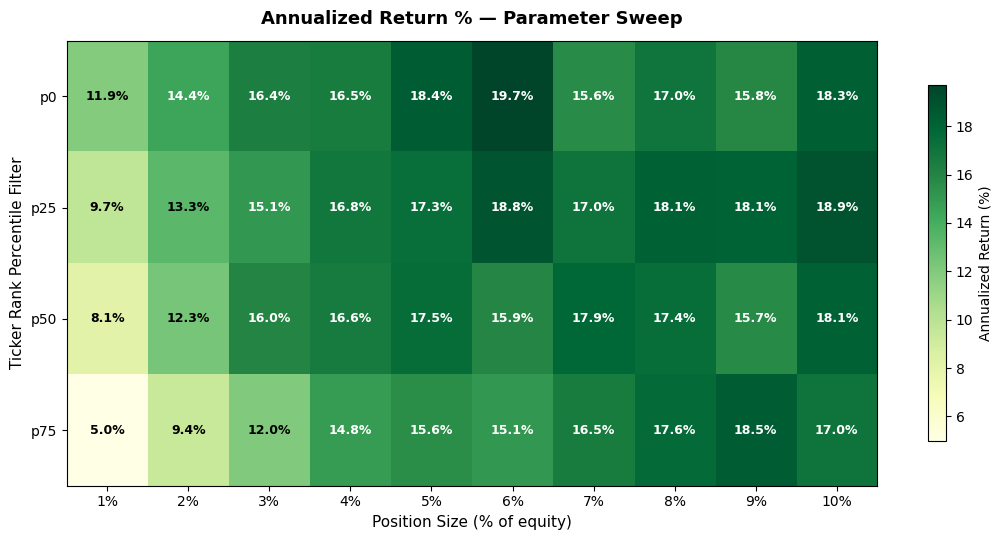

In [121]:
## HEATMAP — Annualized Return % for every parameter combination

pct_vals  = sorted({r["percentile"]    for r in results})
alloc_vals = sorted({r["allocation_pct"] for r in results})

# Build matrix: rows = percentiles (top → bottom), cols = allocations (left → right)
matrix = []
for pct in pct_vals:
    row = []
    for alloc in alloc_vals:
        match = next(
            (r for r in results
             if r["percentile"] == pct and abs(r["allocation_pct"] - alloc) < 1e-9),
            None
        )
        row.append(match["annualized_return"] * 100 if match else float("nan"))
    matrix.append(row)

import numpy as np
matrix = np.array(matrix)

row_labels = [f"p{int(p * 100)}" for p in pct_vals]
col_labels = [f"{int(a * 100)}%" for a in alloc_vals]

fig, ax = plt.subplots(figsize=(max(6, len(col_labels) * 1.1), len(row_labels) + 1.5))

im = ax.imshow(matrix, cmap="YlGn", aspect="auto",
               vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)
ax.set_xlabel("Position Size (% of equity)", fontsize=11)
ax.set_ylabel("Ticker Rank Percentile Filter", fontsize=11)
ax.set_title("Annualized Return % — Parameter Sweep", fontsize=13, fontweight="bold", pad=12)

# Annotate each cell with the return value; use white text on dark cells
norm_range = np.nanmax(matrix) - np.nanmin(matrix)
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        val = matrix[i, j]
        if not np.isnan(val):
            brightness = (val - np.nanmin(matrix)) / (norm_range + 1e-9)
            text_color = "white" if brightness > 0.6 else "black"
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                    fontsize=9, color=text_color, fontweight="bold")

plt.colorbar(im, ax=ax, label="Annualized Return (%)", shrink=0.8)
plt.tight_layout()
plt.show()

In [122]:
import ipywidgets as widgets
from IPython.display import display, clear_output

pct_options   = sorted({r["percentile"]    for r in results})
alloc_options = sorted({r["allocation_pct"] for r in results})

pct_dropdown = widgets.Dropdown(
    options   = [(f"p{int(p*100)}", p) for p in pct_options],
    value     = pct_options[0],
    description = "Percentile:",
)
alloc_dropdown = widgets.Dropdown(
    options   = [(f"{int(a*100)}%", a) for a in alloc_options],
    value     = alloc_options[0],
    description = "Position Size:",
)
out = widgets.Output()

def show_trades(_=None):
    pct   = pct_dropdown.value
    alloc = alloc_dropdown.value
    match = next(
        (r for r in results
         if r["percentile"] == pct and abs(r["allocation_pct"] - alloc) < 1e-9),
        None,
    )
    with out:
        clear_output(wait=True)
        if match is None:
            print("No result found for this combination.")
        else:
            df = match["closed_trades"]
            tp = (df["Reason"] == "TAKE_PROFIT").sum()
            sl = (df["Reason"] == "STOP_LOSS").sum()
            print(f"p{int(pct*100)}, {int(alloc*100)}% alloc  |  "
                  f"{len(df)} trades  |  "
                  f"win rate: {(df['PnL']>0).mean()*100:.1f}%  |  "
                  f"avg PnL: ${df['PnL'].mean():,.2f}  |  "
                  f"take profit: {tp}  |  stop loss: {sl}")
            #pd.set_option('display.max_rows', None)# uncomment to show all trades, but beware of very long lists!
            display(df)
            pd.reset_option('display.max_rows')

pct_dropdown.observe(show_trades,   names="value")
alloc_dropdown.observe(show_trades, names="value")

display(widgets.HBox([pct_dropdown, alloc_dropdown]), out)
show_trades()


Output()

In [123]:
import ipywidgets as widgets
from IPython.display import display, clear_output

pct_options_eq   = sorted({r["percentile"]    for r in results})
alloc_options_eq = sorted({r["allocation_pct"] for r in results})

pct_dropdown_eq = widgets.Dropdown(
    options     = [(f"p{int(p*100)}", p) for p in pct_options_eq],
    value       = pct_options_eq[0],
    description = "Percentile:",
)
alloc_dropdown_eq = widgets.Dropdown(
    options     = [(f"{int(a*100)}%", a) for a in alloc_options_eq],
    value       = alloc_options_eq[0],
    description = "Position Size:",
)
out_eq = widgets.Output()

def show_equity(_=None):
    pct   = pct_dropdown_eq.value
    alloc = alloc_dropdown_eq.value
    match = next(
        (r for r in results
         if r["percentile"] == pct and abs(r["allocation_pct"] - alloc) < 1e-9),
        None,
    )
    with out_eq:
        clear_output(wait=True)
        if match is None:
            print("No result found for this combination.")
        else:
            plot_equity_vs_sp500(match, sp500_prices)

pct_dropdown_eq.observe(show_equity,   names="value")
alloc_dropdown_eq.observe(show_equity, names="value")

display(widgets.HBox([pct_dropdown_eq, alloc_dropdown_eq]), out_eq)
show_equity()


Output()